# Simulation Analysis

This file is to be used to analyse observable quantities of a simulation

In [1]:

import sys
from pathlib import Path

if sys.platform == "darwin":
    proj = "/Users/rileymcnamara/CODE/2025/silicokit/"
    sys.path.insert(0, proj)
else:
    proj = "C:/Users/riley.mcnamara/Documents/code/silicokit/"
    sys.path.insert(0, proj)

from src.growkit.PlotEngine.SimPlotter import SimPlotter
from src.growkit.PlotEngine.CellFieldPlotter import CellFieldPlotter
from src.growkit.Simulator import TumorGrowthSimulator

simulator = TumorGrowthSimulator(proj + "/configs/T_N.yaml")

simulation_data = simulator.load_simulation_data(proj + "/laboratory/saved_simulations/simulation_data.npz")

sim_plotter = SimPlotter(simulation_data)
cell_plotter = CellFieldPlotter(simulation_data, simulator=simulator)


Pre-compiling Numba functions...
Numba functions compiled successfully!
Loading simulation data from /Users/rileymcnamara/CODE/2025/silicokit//laboratory/saved_simulations/simulation_data.npz...
Loaded simulation data with 21 saved steps


## Radius Evolution

Calculating tumor radius evolution...
Calculating inhibited radius evolution...
Calculating necrotic radius evolution...
Calculating hypoxic radius evolution...


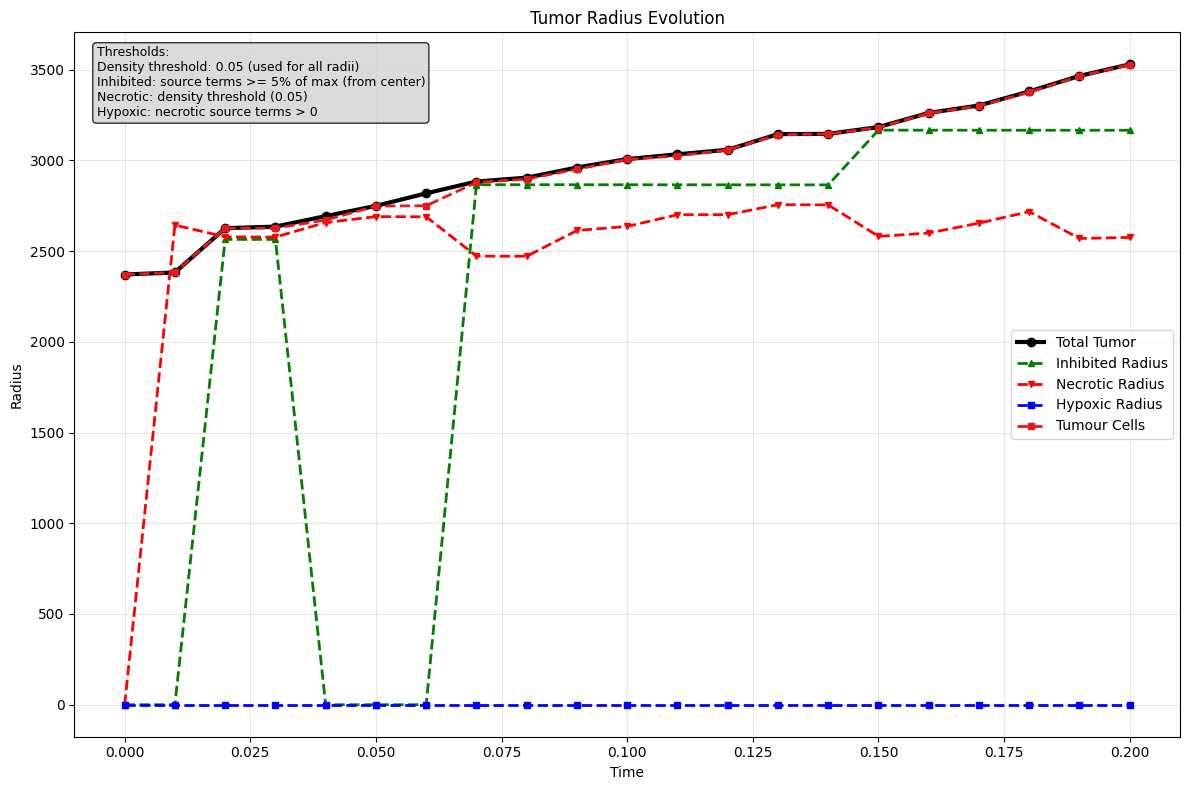

{'total_radii': [np.float64(2370.7213167715126),
  np.float64(2382.1822934020825),
  np.float64(2626.0347822832064),
  np.float64(2634.757564273923),
  np.float64(2692.6977013966816),
  np.float64(2748.9462411157224),
  np.float64(2818.2643961365047),
  np.float64(2883.224150135298),
  np.float64(2904.5986215826442),
  np.float64(2960.485453431189),
  np.float64(3006.9572721319178),
  np.float64(3033.3698147715063),
  np.float64(3058.2300781118474),
  np.float64(3144.4511438233417),
  np.float64(3145.8478731409155),
  np.float64(3183.284930581011),
  np.float64(3261.45717646044),
  np.float64(3302.114426238989),
  np.float64(3379.755015353839),
  np.float64(3465.3146611776597),
  np.float64(3529.0049331916384)],
 'population_radii': {'Tumour Cells': [np.float64(2370.7213167715126),
   np.float64(2382.1829064334356),
   np.float64(2626.012787700178),
   np.float64(2626.2999772615253),
   np.float64(2670.737893452605),
   np.float64(2747.8753029489344),
   np.float64(2749.8349976852846),

In [2]:
sim_plotter.plot_tumor_radius_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), include_individual_populations=True, threshold=0.05, method='contour', growth_threshold=0.45)

In [3]:
#sim_plotter.plot_density_and_source_with_radii()

## Population Density Evolution

Plotting evolution for population: Tumour Cells (index: 0)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


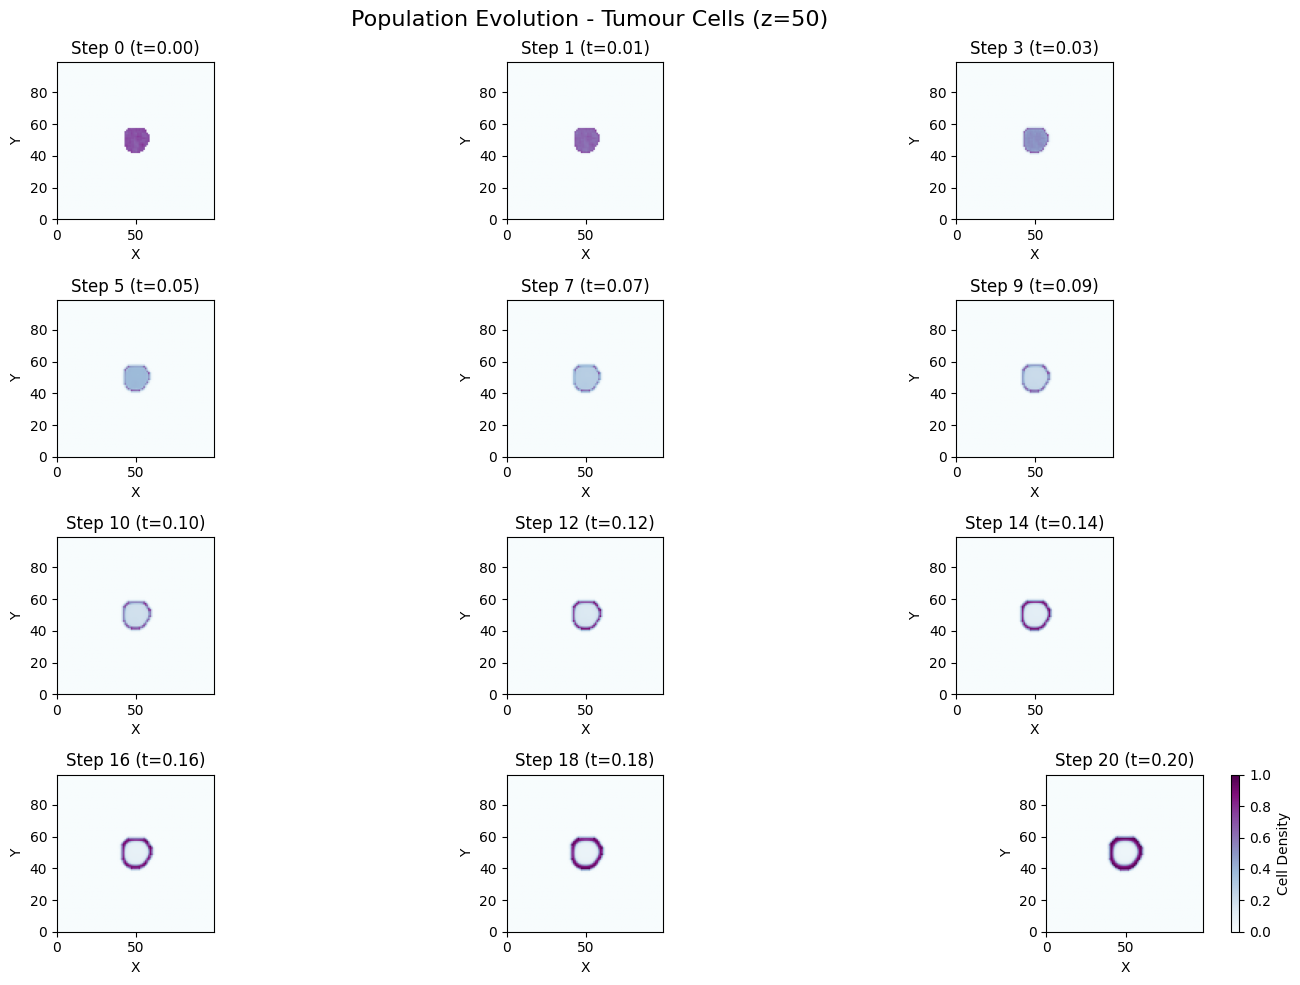

In [4]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Tumour Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Necrotic Cells (index: 1)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


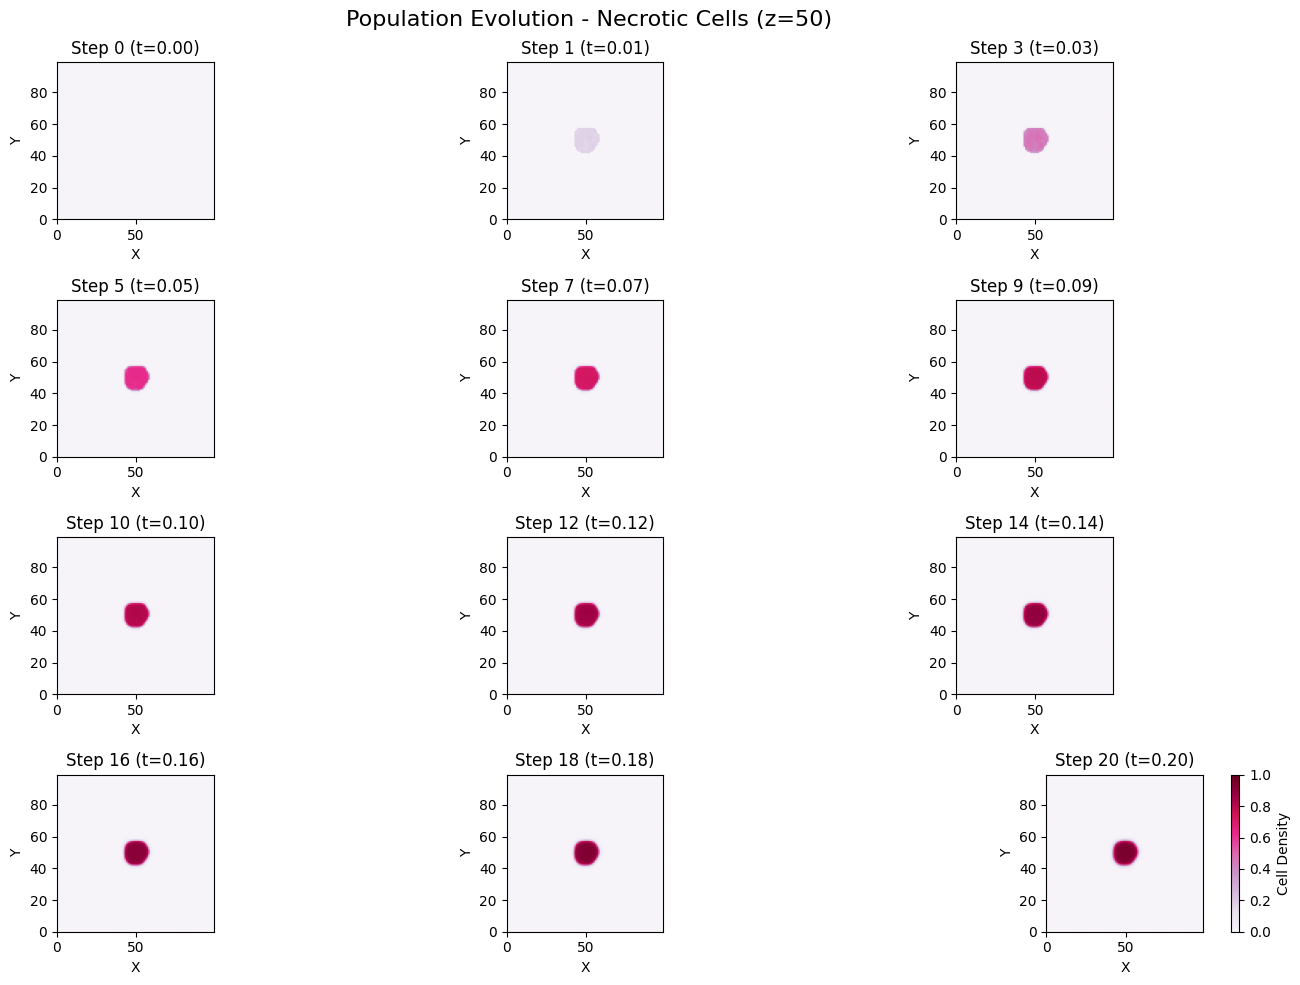

In [5]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Necrotic Cells", cmap="PuRd", show_plot=True)

Creating nutrient field evolution plot...


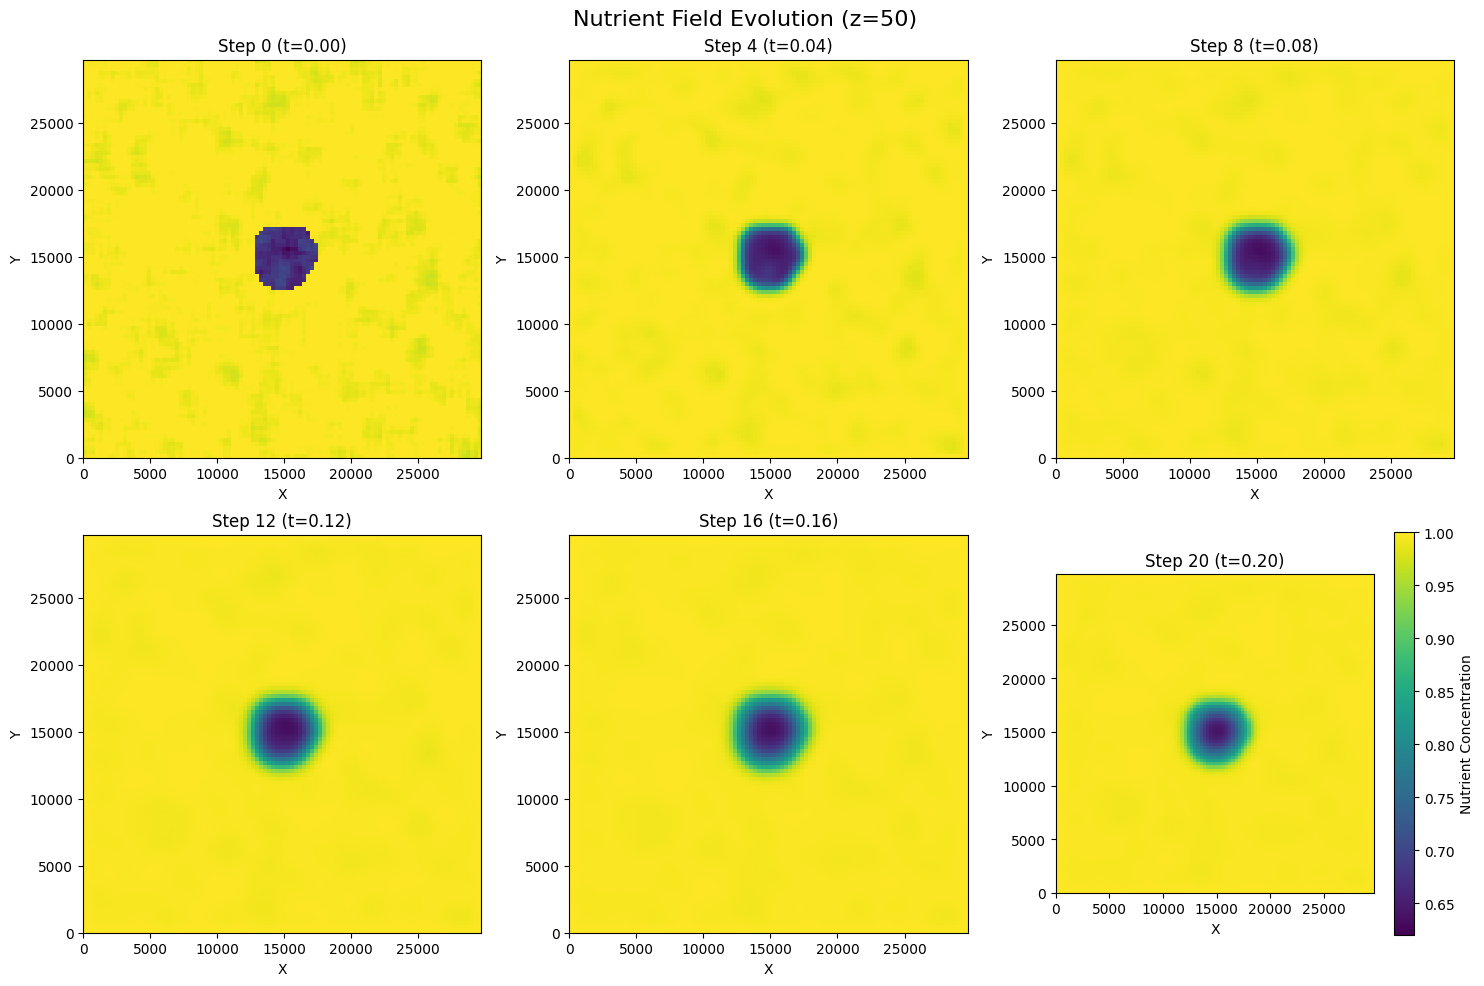

In [6]:
sim_plotter.plot_nutrient_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="viridis", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating source field evolution plot...


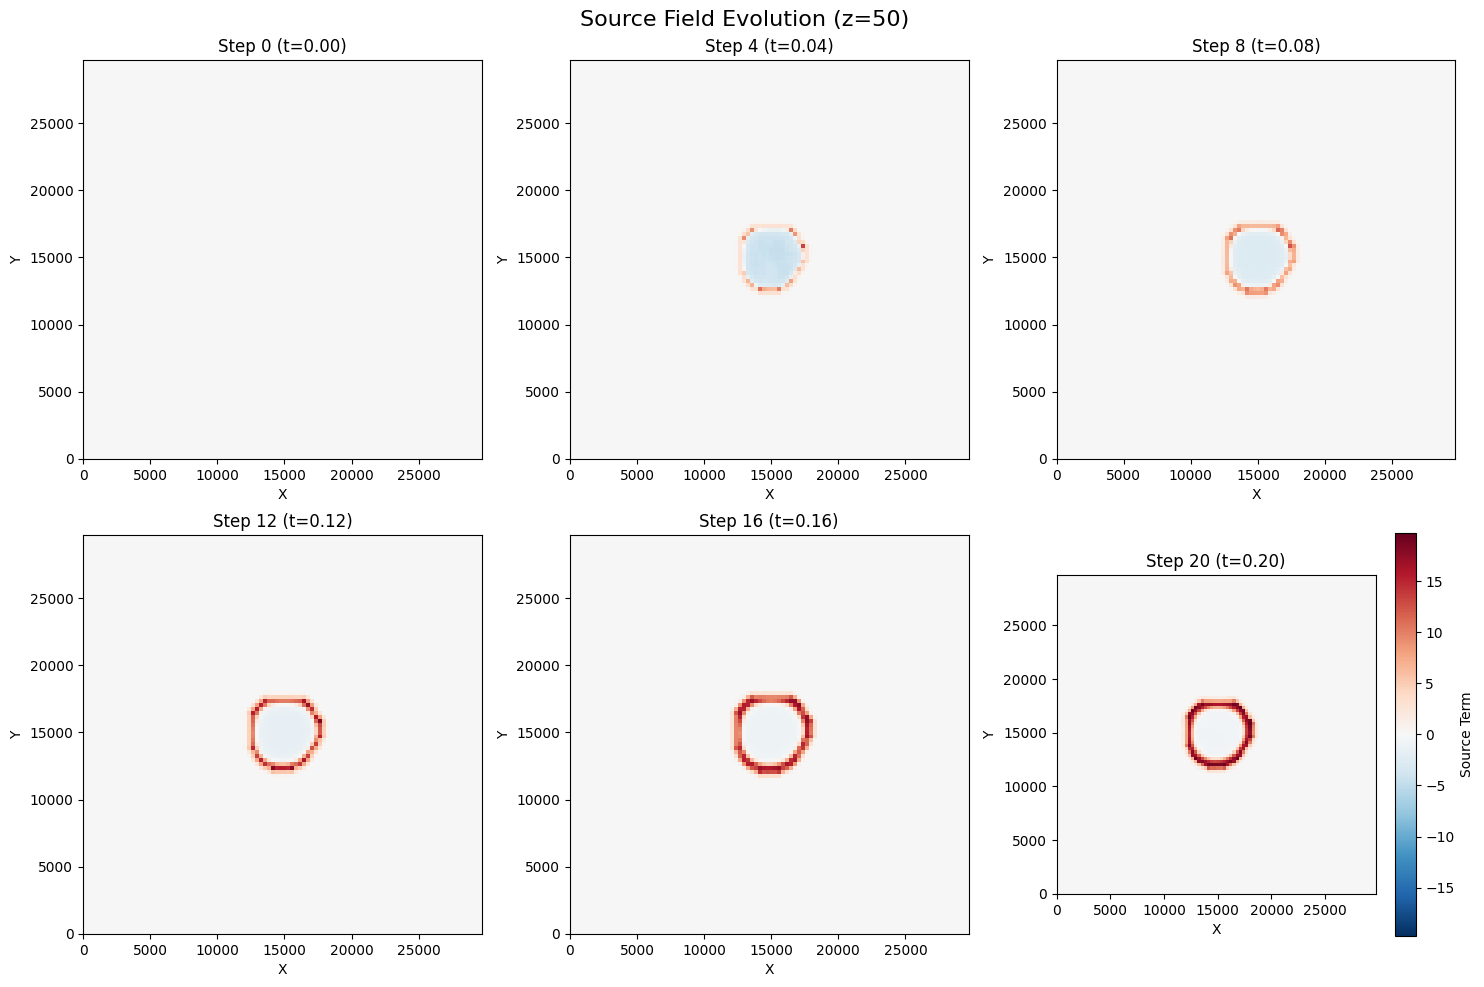

In [7]:
sim_plotter.plot_source_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="RdBu_r", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating radius diagnostic plot...


/Users/rileymcnamara/CODE/2025/silicokit/src/growkit/PlotEngine/SimPlotter.py:2507: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(edge_radial, edge_populations[label], c=colors[j], s=12,


Radius diagnostic plot saved to path/to/output/radius_diagnostic_z50_threshold0.1.png


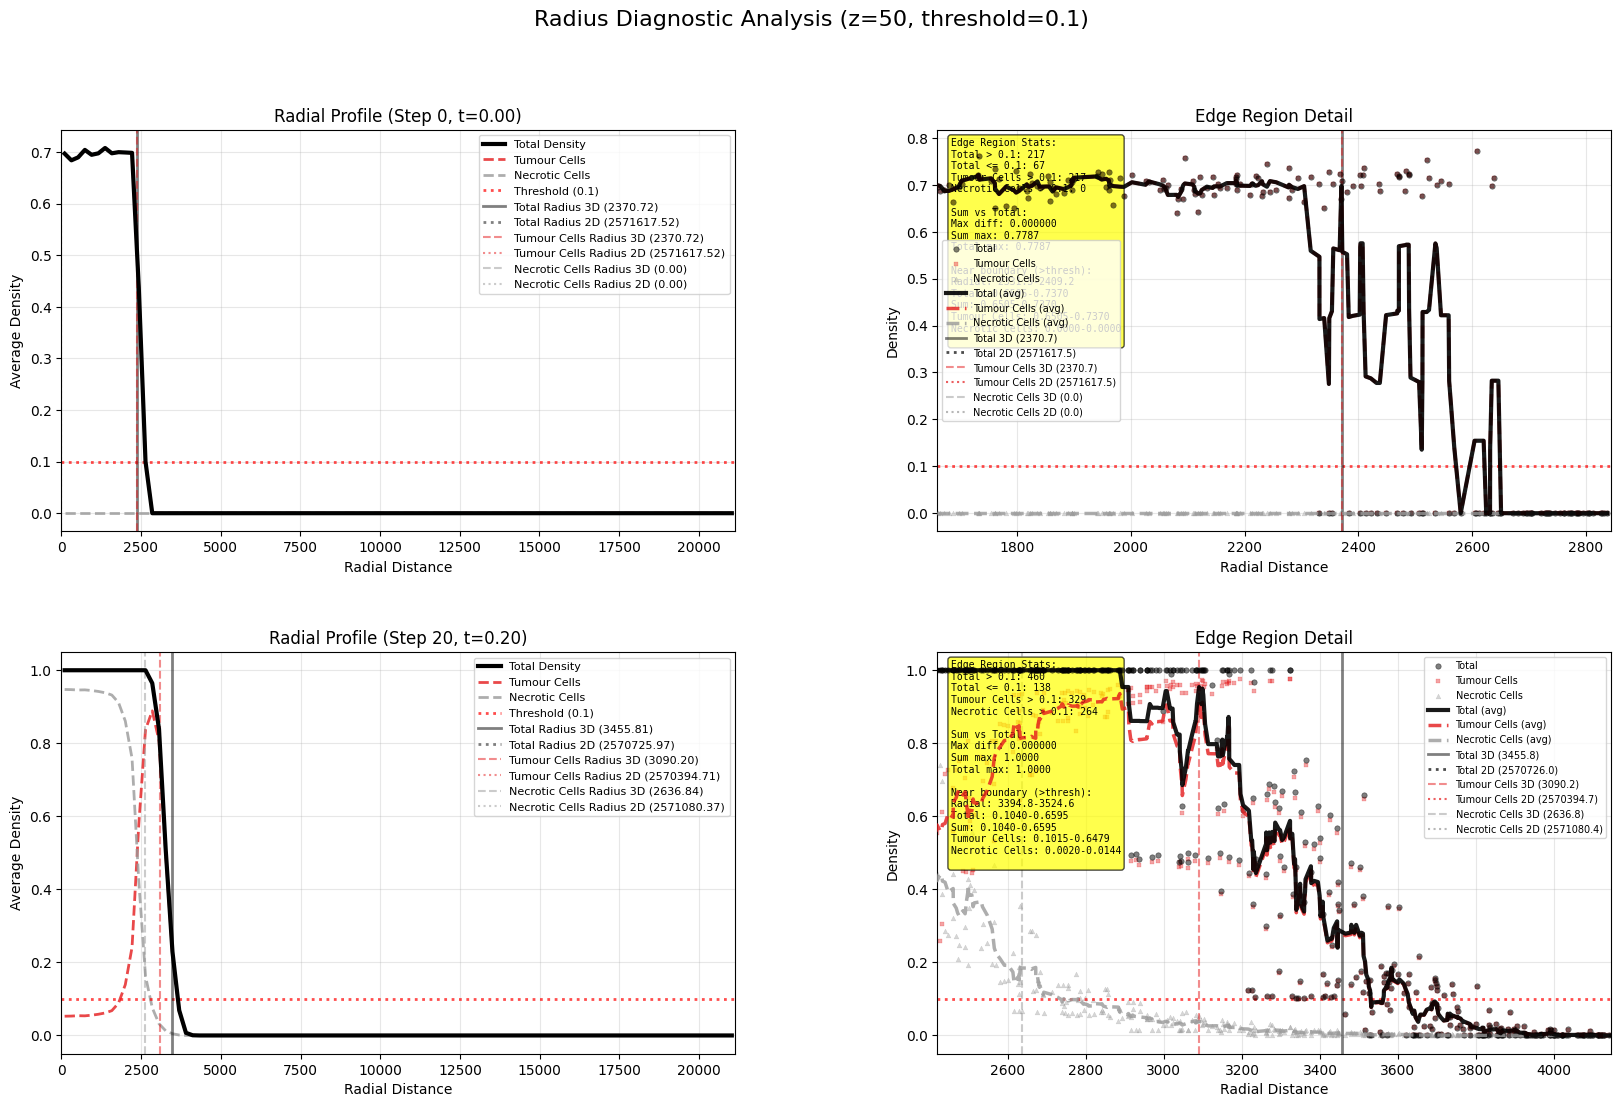

{'step_indices': [0, 20],
 'individual_radii': {0: {'Tumour Cells': np.float64(2370.7213167715126),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(3090.197751228683),
   'Necrotic Cells': np.float64(2636.836904311091)}},
 'total_radii': {0: np.float64(2370.7213167715126),
  20: np.float64(3455.8147129567997)},
 'z_slice': 50,
 'threshold': 0.1,
 'total_radii_2d': {0: np.float64(2571617.5229413873),
  20: np.float64(2570725.965838198)},
 'individual_radii_2d': {0: {'Tumour Cells': np.float64(2571617.5229413873),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(2570394.7096436475),
   'Necrotic Cells': np.float64(2571080.3650202896)}}}

In [8]:
# In your notebook or script:
sim_plotter.plot_radius_diagnostic(
    output_dir='path/to/output',
    save_plot=True,
    step_indices=[0, 50, -1],  # Compare early, middle, and late time steps
    threshold=0.1,  # Use the same threshold as your radius plot
    method='contour'
)